In [2]:
import pandas as pd
import os

folder = "demand data"

if not os.path.exists(folder):
    print("can't find the folder")
    print("current Jupyter catalog is：")
    print(os.getcwd())
    print("\n the folder in current folder：")
    print(os.listdir())
else:
    print("find the folder：", folder)

files = os.listdir(folder)

csv_files = [
    f for f in files
    if f.lower().endswith(".csv")
]

print("\n the number of CSV folders:", len(csv_files))


print("\n first 10 folders：")

for file in csv_files[:10]:
    print(file)


headers = {}

for file in csv_files:
    
    path = os.path.join(folder, file)
    
    try:
        df = pd.read_csv(path)
  
        columns = tuple(df.columns)
        
        if columns not in headers:
            headers[columns] = []
        
        headers[columns].append(file)
    
    except Exception as e:
        print("\nfail to read:", file)
        print("fail:", e)



print("\n================================")
print("Different CSV title")
print("================================")

for i, (header, file_list) in enumerate(headers.items(), 1):
    
    print(f"\nHeader {i}")
    print("number of folders:", len(file_list))
    print("header:", list(header))
    
    print("some of the folders:")
    for file in file_list[:3]:
        print("  ", file)

find the folder： demand data

 the number of CSV folders: 1095

 first 10 folders：
DATA200001_NSW1.csv
DATA200001_QLD1.csv
DATA200001_VIC1.csv
DATA200002_NSW1.csv
DATA200002_QLD1.csv
DATA200002_VIC1.csv
DATA200003_NSW1.csv
DATA200003_QLD1.csv
DATA200003_SA1.csv
DATA200004_NSW1.csv

Different CSV title

Header 1
number of folders: 1095
header: ['REGION', 'SETTLEMENTDATE', 'TOTALDEMAND', 'RRP', 'PERIODTYPE']
some of the folders:
   DATA200001_NSW1.csv
   DATA200001_QLD1.csv
   DATA200001_VIC1.csv


In [3]:
import pandas as pd
import os

folder = "demand data"

test_files = [
    "DATA200001_NSW1.csv",
    "DATA200001_QLD1.csv",
    "DATA200001_VIC1.csv",
    "DATA200003_SA1.csv"
]

for file in test_files:
    
    path = os.path.join(folder, file)
    
    print("\n" + "=" * 60)
    print("folder:", file)
    
    try:
        df = pd.read_csv(path)
        
        print("the size of data:", df.shape)
        print("Columns:")
        print(df.columns.tolist())
        
        print("\nfirst 5 columns:")
        display(df.head())
        
    except Exception as e:
        print("fail to read:", e)


folder: DATA200001_NSW1.csv
the size of data: (1488, 5)
Columns:
['REGION', 'SETTLEMENTDATE', 'TOTALDEMAND', 'RRP', 'PERIODTYPE']

first 5 columns:


,REGION,SETTLEMENTDATE,TOTALDEMAND,RRP,PERIODTYPE
0,NSW1,2000/01/01 00:30,6763.57000,15.64,TRADE
1,NSW1,2000/01/01 01:00,6386.10167,14.06,TRADE
2,NSW1,2000/01/01 01:30,5990.79500,14.30,TRADE
3,NSW1,2000/01/01 02:00,5655.97667,14.28,TRADE
4,NSW1,2000/01/01 02:30,5283.83667,14.17,TRADE



folder: DATA200001_QLD1.csv
the size of data: (1488, 5)
Columns:
['REGION', 'SETTLEMENTDATE', 'TOTALDEMAND', 'RRP', 'PERIODTYPE']

first 5 columns:


,REGION,SETTLEMENTDATE,TOTALDEMAND,RRP,PERIODTYPE
0,QLD1,2000/01/01 00:30,3905.56833,39.40,TRADE
1,QLD1,2000/01/01 01:00,3855.67500,34.18,TRADE
2,QLD1,2000/01/01 01:30,3814.44667,35.20,TRADE
3,QLD1,2000/01/01 02:00,3705.36500,25.53,TRADE
4,QLD1,2000/01/01 02:30,3615.71333,18.55,TRADE



folder: DATA200001_VIC1.csv
the size of data: (1488, 5)
Columns:
['REGION', 'SETTLEMENTDATE', 'TOTALDEMAND', 'RRP', 'PERIODTYPE']

first 5 columns:


,REGION,SETTLEMENTDATE,TOTALDEMAND,RRP,PERIODTYPE
0,VIC1,2000/01/01 00:30,4419.03667,9.97,TRADE
1,VIC1,2000/01/01 01:00,4312.54000,12.58,TRADE
2,VIC1,2000/01/01 01:30,4599.70167,13.22,TRADE
3,VIC1,2000/01/01 02:00,4478.99000,12.90,TRADE
4,VIC1,2000/01/01 02:30,4228.81000,12.40,TRADE



folder: DATA200003_SA1.csv
the size of data: (1487, 5)
Columns:
['REGION', 'SETTLEMENTDATE', 'TOTALDEMAND', 'RRP', 'PERIODTYPE']

first 5 columns:


,REGION,SETTLEMENTDATE,TOTALDEMAND,RRP,PERIODTYPE
0,SA1,2000/03/01 00:30,1669.71667,40.55,TRADE
1,SA1,2000/03/01 01:00,1661.18500,40.55,TRADE
2,SA1,2000/03/01 01:30,1548.31167,28.51,TRADE
3,SA1,2000/03/01 02:00,1437.09833,19.29,TRADE
4,SA1,2000/03/01 02:30,1382.26667,21.21,TRADE


In [4]:
import pandas as pd
import os


folder = "demand data"


csv_files = [
    f for f in os.listdir(folder)
    if f.lower().endswith(".csv")
]

print("the number of CSV folders:", len(csv_files))


# ==========================================
# 3. 读取所有 CSV
# ==========================================

all_demand = []

for file in csv_files:
    
    path = os.path.join(folder, file)
    
    try:
        df = pd.read_csv(path)
        
        df = df[
            ["REGION", "SETTLEMENTDATE", "TOTALDEMAND"]
        ].copy()
      
        df["SOURCE_FILE"] = file
        
        all_demand.append(df)
        
    except Exception as e:
        print("fail to read:", file)
        print("fail:", e)


demand = pd.concat(
    all_demand,
    ignore_index=True
)



print("\nsucceed to merge！")

print("the size of data:", demand.shape)

display(demand.head())

print("\nColumns:")
print(demand.columns.tolist())

the number of CSV folders: 1095

succeed to merge！
the size of data: (1599066, 4)


,REGION,SETTLEMENTDATE,TOTALDEMAND,SOURCE_FILE
0,NSW1,2000/01/01 00:30,6763.57000,DATA200001_NSW1.csv
1,NSW1,2000/01/01 01:00,6386.10167,DATA200001_NSW1.csv
2,NSW1,2000/01/01 01:30,5990.79500,DATA200001_NSW1.csv
3,NSW1,2000/01/01 02:00,5655.97667,DATA200001_NSW1.csv
4,NSW1,2000/01/01 02:30,5283.83667,DATA200001_NSW1.csv



Columns:
['REGION', 'SETTLEMENTDATE', 'TOTALDEMAND', 'SOURCE_FILE']


In [5]:


demand["SETTLEMENTDATE"] = pd.to_datetime(
    demand["SETTLEMENTDATE"],
    format="%Y/%m/%d %H:%M",
    errors="coerce"
)

print("succeed to transform the date")

print(demand.dtypes)

display(demand.head())

succeed to transform the date
REGION                    object
SETTLEMENTDATE    datetime64[ns]
TOTALDEMAND              float64
SOURCE_FILE               object
dtype: object


,REGION,SETTLEMENTDATE,TOTALDEMAND,SOURCE_FILE
0,NSW1,2000-01-01 00:30:00,6763.57000,DATA200001_NSW1.csv
1,NSW1,2000-01-01 01:00:00,6386.10167,DATA200001_NSW1.csv
2,NSW1,2000-01-01 01:30:00,5990.79500,DATA200001_NSW1.csv
3,NSW1,2000-01-01 02:00:00,5655.97667,DATA200001_NSW1.csv
4,NSW1,2000-01-01 02:30:00,5283.83667,DATA200001_NSW1.csv


In [6]:
# Check missing values
print("Missing values:")
print(demand.isnull().sum())

Missing values:
REGION                  0
SETTLEMENTDATE    1371141
TOTALDEMAND             0
SOURCE_FILE             0
dtype: int64


In [7]:
# Check number of observations by region
print(
    demand["REGION"].value_counts()
)

REGION
SA1     341896
QLD1    340460
VIC1    333065
NSW1    327208
TAS1    256437
Name: count, dtype: int64


In [8]:
import pandas as pd
import os
# 1. Folder
folder = "demand data"

# 2. Get all CSV files
csv_files = [
    f for f in os.listdir(folder)
    if f.lower().endswith(".csv")
]

print("CSV files:", len(csv_files))

# 3. Read all files
all_demand = []

for file in csv_files:
    
    path = os.path.join(folder, file)
    
    try:
        df = pd.read_csv(path)
        
        df = df[
            ["REGION", "SETTLEMENTDATE", "TOTALDEMAND"]
        ].copy()
        
        df["SOURCE_FILE"] = file
        
        all_demand.append(df)
        
    except Exception as e:
        print("Failed:", file)
        print(e)

# 4. Combine
demand = pd.concat(
    all_demand,
    ignore_index=True
)

# 5. Convert date/time
demand["SETTLEMENTDATE"] = pd.to_datetime(
    demand["SETTLEMENTDATE"],
    errors="coerce"
)

# 6. Check results
print("\nData shape:")
print(demand.shape)

print("\nData types:")
print(demand.dtypes)

print("\nMissing values:")
print(demand.isnull().sum())

CSV files: 1095

Data shape:
(1599066, 4)

Data types:
REGION                    object
SETTLEMENTDATE    datetime64[ns]
TOTALDEMAND              float64
SOURCE_FILE               object
dtype: object

Missing values:
REGION                  0
SETTLEMENTDATE    1371141
TOTALDEMAND             0
SOURCE_FILE             0
dtype: int64


In [9]:
import pandas as pd
import os

folder = "demand data"
for file in os.listdir(folder):
    
    if file.endswith(".csv"):
        
        path = os.path.join(folder, file)
        
        df_test = pd.read_csv(path)
        
        print("file:", file)
        print(df_test.head())
        print("\nthe type of raw date:")
        print(df_test["SETTLEMENTDATE"].dtype)
        
        break

file: DATA200001_NSW1.csv
  REGION    SETTLEMENTDATE  TOTALDEMAND    RRP PERIODTYPE
0   NSW1  2000/01/01 00:30   6763.57000  15.64      TRADE
1   NSW1  2000/01/01 01:00   6386.10167  14.06      TRADE
2   NSW1  2000/01/01 01:30   5990.79500  14.30      TRADE
3   NSW1  2000/01/01 02:00   5655.97667  14.28      TRADE
4   NSW1  2000/01/01 02:30   5283.83667  14.17      TRADE

the type of raw date:
object


In [10]:
# Convert date/time correctly
demand["SETTLEMENTDATE"] = pd.to_datetime(
    demand["SETTLEMENTDATE"],
    format="%Y/%m/%d %H:%M",
    errors="coerce"
)

print("Missing dates:")
print(demand["SETTLEMENTDATE"].isna().sum())

print("\nData types:")
print(demand.dtypes)

print("\nFirst 5 rows:")
display(demand.head())

Missing dates:
1371141

Data types:
REGION                    object
SETTLEMENTDATE    datetime64[ns]
TOTALDEMAND              float64
SOURCE_FILE               object
dtype: object

First 5 rows:


,REGION,SETTLEMENTDATE,TOTALDEMAND,SOURCE_FILE
0,NSW1,2000-01-01 00:30:00,6763.57000,DATA200001_NSW1.csv
1,NSW1,2000-01-01 01:00:00,6386.10167,DATA200001_NSW1.csv
2,NSW1,2000-01-01 01:30:00,5990.79500,DATA200001_NSW1.csv
3,NSW1,2000-01-01 02:00:00,5655.97667,DATA200001_NSW1.csv
4,NSW1,2000-01-01 02:30:00,5283.83667,DATA200001_NSW1.csv


In [15]:
import pandas as pd
import os

folder = "demand data"

csv_files = [
    f for f in os.listdir(folder)
    if f.lower().endswith(".csv")
]

all_demand = []

for file in csv_files:
    
    path = os.path.join(folder, file)
    
    try:
        df = pd.read_csv(path)
        
        df = df[
            ["REGION", "SETTLEMENTDATE", "TOTALDEMAND"]
        ].copy()
        
        df["SOURCE_FILE"] = file
        
        all_demand.append(df)
        
    except Exception as e:
        print("Failed:", file)
        print(e)


# Combine
demand_raw = pd.concat(
    all_demand,
    ignore_index=True
)

print("Total rows:", len(demand_raw))


# Try converting the original dates
converted_dates = pd.to_datetime(
    demand_raw["SETTLEMENTDATE"],
    format="%Y/%m/%d %H:%M",
    errors="coerce"
)


# Find dates that failed
bad = demand_raw[converted_dates.isna()].copy()

print("\nNumber of failed dates:", len(bad))

print("\nExamples of failed original dates:")
display(
    bad[
        ["REGION", "SETTLEMENTDATE", "SOURCE_FILE"]
    ].head(20)
)

Total rows: 1599066

Number of failed dates: 1371141

Examples of failed original dates:


,REGION,SETTLEMENTDATE,SOURCE_FILE
227925,QLD1,2003/11/01 00:30:00,DATA200311_QLD1.csv
227926,QLD1,2003/11/01 01:00:00,DATA200311_QLD1.csv
227927,QLD1,2003/11/01 01:30:00,DATA200311_QLD1.csv
227928,QLD1,2003/11/01 02:00:00,DATA200311_QLD1.csv
227929,QLD1,2003/11/01 02:30:00,DATA200311_QLD1.csv
227930,QLD1,2003/11/01 03:00:00,DATA200311_QLD1.csv
227931,QLD1,2003/11/01 03:30:00,DATA200311_QLD1.csv
227932,QLD1,2003/11/01 04:00:00,DATA200311_QLD1.csv
227933,QLD1,2003/11/01 04:30:00,DATA200311_QLD1.csv
227934,QLD1,2003/11/01 05:00:00,DATA200311_QLD1.csv


In [14]:
# Convert date/time

demand_raw["SETTLEMENTDATE"] = pd.to_datetime(
    demand_raw["SETTLEMENTDATE"],
    errors="coerce"
)

print("Missing dates:")
print(demand_raw["SETTLEMENTDATE"].isna().sum())

print("\nData types:")
print(demand_raw.dtypes)

print("\nFirst 5 rows:")
display(demand_raw.head())

Missing dates:
1371141

Data types:
REGION                    object
SETTLEMENTDATE    datetime64[ns]
TOTALDEMAND              float64
SOURCE_FILE               object
dtype: object

First 5 rows:


,REGION,SETTLEMENTDATE,TOTALDEMAND,SOURCE_FILE
0,NSW1,2000-01-01 00:30:00,6763.57000,DATA200001_NSW1.csv
1,NSW1,2000-01-01 01:00:00,6386.10167,DATA200001_NSW1.csv
2,NSW1,2000-01-01 01:30:00,5990.79500,DATA200001_NSW1.csv
3,NSW1,2000-01-01 02:00:00,5655.97667,DATA200001_NSW1.csv
4,NSW1,2000-01-01 02:30:00,5283.83667,DATA200001_NSW1.csv


In [18]:
bad_dates = demand_raw[
    demand_raw["SETTLEMENTDATE"].isna()
]

print("the date which cannot be transformed:", len(bad_dates))

display(
    bad_dates[
        ["REGION", "SETTLEMENTDATE", "SOURCE_FILE"]
    ].head(20)
)

the date which cannot be transformed: 1371141


,REGION,SETTLEMENTDATE,SOURCE_FILE
227925,QLD1,NaT,DATA200311_QLD1.csv
227926,QLD1,NaT,DATA200311_QLD1.csv
227927,QLD1,NaT,DATA200311_QLD1.csv
227928,QLD1,NaT,DATA200311_QLD1.csv
227929,QLD1,NaT,DATA200311_QLD1.csv
227930,QLD1,NaT,DATA200311_QLD1.csv
227931,QLD1,NaT,DATA200311_QLD1.csv
227932,QLD1,NaT,DATA200311_QLD1.csv
227933,QLD1,NaT,DATA200311_QLD1.csv
227934,QLD1,NaT,DATA200311_QLD1.csv


In [17]:
demand_raw["SETTLEMENTDATE"] = pd.to_datetime(
    demand_raw["SETTLEMENTDATE"],
    errors="coerce"
)

print("Missing dates:")
print(demand_raw["SETTLEMENTDATE"].isna().sum())

print("\nData types:")
print(demand_raw.dtypes)

Missing dates:
1371141

Data types:
REGION                    object
SETTLEMENTDATE    datetime64[ns]
TOTALDEMAND              float64
SOURCE_FILE               object
dtype: object


In [19]:
import pandas as pd
import os

folder = "demand data"

csv_files = [
    f for f in os.listdir(folder)
    if f.lower().endswith(".csv")
]

format_results = []

for file in csv_files:
    
    path = os.path.join(folder, file)
    
    try:
        df = pd.read_csv(path)
        
        sample = str(df["SETTLEMENTDATE"].iloc[0])
        
        test1 = pd.to_datetime(
            sample,
            format="%Y/%m/%d %H:%M",
            errors="coerce"
        )
        
        test2 = pd.to_datetime(
            sample,
            format="%Y/%m/%d %H:%M:%S",
            errors="coerce"
        )
        
        if not pd.isna(test1):
            date_format = "YYYY/MM/DD HH:MM"
            
        elif not pd.isna(test2):
            date_format = "YYYY/MM/DD HH:MM:SS"
            
        else:
            date_format = "OTHER"
        
        format_results.append(
            [file, sample, date_format]
        )
        
    except Exception as e:
        format_results.append(
            [file, "ERROR", str(e)]
        )

format_check = pd.DataFrame(
    format_results,
    columns=["FILE", "SAMPLE_DATE", "DATE_FORMAT"]
)

print("the number of files with different types of dates：")
print(format_check["DATE_FORMAT"].value_counts())

print("\nexamples of different types of dates：")

for fmt in format_check["DATE_FORMAT"].unique():
    
    print("\n==============================")
    print("form:", fmt)
    
    display(
        format_check[
            format_check["DATE_FORMAT"] == fmt
        ].head(5)
    )

the number of files with different types of dates：
DATE_FORMAT
YYYY/MM/DD HH:MM:SS    934
YYYY/MM/DD HH:MM       156
OTHER                    5
Name: count, dtype: int64

examples of different types of dates：

form: YYYY/MM/DD HH:MM


,FILE,SAMPLE_DATE,DATE_FORMAT
0,DATA200001_NSW1.csv,2000/01/01 00:30,YYYY/MM/DD HH:MM
1,DATA200001_QLD1.csv,2000/01/01 00:30,YYYY/MM/DD HH:MM
2,DATA200001_VIC1.csv,2000/01/01 00:30,YYYY/MM/DD HH:MM
3,DATA200002_NSW1.csv,2000/02/01 00:30,YYYY/MM/DD HH:MM
4,DATA200002_QLD1.csv,2000/02/01 00:30,YYYY/MM/DD HH:MM



form: YYYY/MM/DD HH:MM:SS


,FILE,SAMPLE_DATE,DATE_FORMAT
156,DATA200311_QLD1.csv,2003/11/01 00:30:00,YYYY/MM/DD HH:MM:SS
157,DATA200311_SA1.csv,2003/11/01 00:30:00,YYYY/MM/DD HH:MM:SS
158,DATA200311_VIC1.csv,2003/11/01 00:30:00,YYYY/MM/DD HH:MM:SS
159,DATA200312_NSW1.csv,2003/12/01 00:30:00,YYYY/MM/DD HH:MM:SS
160,DATA200312_QLD1.csv,2003/12/01 00:30:00,YYYY/MM/DD HH:MM:SS



form: OTHER


,FILE,SAMPLE_DATE,DATE_FORMAT
895,DATA201609_NSW1.csv,01/09/2016 00:30:00,OTHER
896,DATA201609_QLD1.csv,01/09/2016 00:30:00,OTHER
897,DATA201609_SA1.csv,01/09/2016 00:30:00,OTHER
898,DATA201609_TAS1.csv,01/09/2016 00:30:00,OTHER
899,DATA201609_VIC1.csv,01/09/2016 00:30:00,OTHER


In [49]:
import pandas as pd
import os

# ==========================================
# 1. Set folder
# ==========================================

folder = "demand data"

csv_files = [
    f for f in os.listdir(folder)
    if f.lower().endswith(".csv")
]

print("Number of CSV files:", len(csv_files))


# ==========================================
# 2. Read and clean every CSV
# ==========================================

all_demand = []

for file in csv_files:
    
    path = os.path.join(folder, file)
    
    try:
        df = pd.read_csv(path)
        
        # Keep only columns needed for this project
        df = df[
            ["REGION", "SETTLEMENTDATE", "TOTALDEMAND"]
        ].copy()
        
        # --------------------------------------
        # Convert different date formats
        # --------------------------------------
        
        date_text = df["SETTLEMENTDATE"].astype(str)
        
        # Format 1:
        # YYYY/MM/DD HH:MM
        dates_1 = pd.to_datetime(
            date_text,
            format="%Y/%m/%d %H:%M",
            errors="coerce"
        )
        
        # Format 2:
        # YYYY/MM/DD HH:MM:SS
        dates_2 = pd.to_datetime(
            date_text,
            format="%Y/%m/%d %H:%M:%S",
            errors="coerce"
        )
        
        # Format 3:
        # DD/MM/YYYY HH:MM:SS
        dates_3 = pd.to_datetime(
            date_text,
            format="%d/%m/%Y %H:%M:%S",
            errors="coerce"
        )
        
        # Combine the three formats
        df["SETTLEMENTDATE"] = (
            dates_1
            .fillna(dates_2)
            .fillna(dates_3)
        )
        
        # Save original file name
        df["SOURCE_FILE"] = file
        
        all_demand.append(df)
        
    except Exception as e:
        print("Failed to read:", file)
        print("Error:", e)


# ==========================================
# 3. Combine all files
# ==========================================

demand = pd.concat(
    all_demand,
    ignore_index=True
)


# ==========================================
# 4. Check final result
# ==========================================

print("\n==========================================")
print("Demand data successfully combined")
print("==========================================")

print("Number of rows:", len(demand))

print("\nData types:")
print(demand.dtypes)

print("\nMissing values:")
print(demand.isnull().sum())

print("\nFirst 5 rows:")
display(demand.head())

Number of CSV files: 1095

Demand data successfully combined
Number of rows: 1599066

Data types:
REGION                    object
SETTLEMENTDATE    datetime64[ns]
TOTALDEMAND              float64
SOURCE_FILE               object
dtype: object

Missing values:
REGION            0
SETTLEMENTDATE    0
TOTALDEMAND       0
SOURCE_FILE       0
dtype: int64

First 5 rows:


,REGION,SETTLEMENTDATE,TOTALDEMAND,SOURCE_FILE
0,NSW1,2000-01-01 00:30:00,6763.57000,DATA200001_NSW1.csv
1,NSW1,2000-01-01 01:00:00,6386.10167,DATA200001_NSW1.csv
2,NSW1,2000-01-01 01:30:00,5990.79500,DATA200001_NSW1.csv
3,NSW1,2000-01-01 02:00:00,5655.97667,DATA200001_NSW1.csv
4,NSW1,2000-01-01 02:30:00,5283.83667,DATA200001_NSW1.csv


In [51]:
# Check the date range of the demand data

print("Earliest date:")
print(demand["SETTLEMENTDATE"].min())

print("\nLatest date:")
print(demand["SETTLEMENTDATE"].max())

# Check regions and number of observations

print("\nRegions:")
print(demand["REGION"].unique())

print("\nNumber of observations by region:")
print(demand.groupby("REGION").size())

# Check duplicated observations

duplicates = demand.duplicated(
    subset=["REGION", "SETTLEMENTDATE"]
).sum()

print("\nDuplicated observations:")
print(duplicates)

Earliest date:
2000-01-01 00:30:00

Latest date:
2020-01-01 00:00:00

Regions:
['NSW1' 'QLD1' 'VIC1' 'SA1' 'TAS1']

Number of observations by region:
REGION
NSW1    327208
QLD1    340460
SA1     341896
TAS1    256437
VIC1    333065
dtype: int64

Duplicated observations:
0


In [20]:
# Check gaps in the half-hourly time series

# Sort data by region and time
demand = demand.sort_values(
    ["REGION", "SETTLEMENTDATE"]
).reset_index(drop=True)

# Calculate time difference between consecutive observations
demand["TIME_DIFF"] = (
    demand.groupby("REGION")["SETTLEMENTDATE"].diff()
)

# The first observation of each region has no previous observation,
# so exclude those rows
time_gaps = demand[
    demand["TIME_DIFF"].notna()
    & (demand["TIME_DIFF"] != pd.Timedelta(minutes=30))
]

print("Number of unusual time intervals:")
print(len(time_gaps))

print("\nTypes of unusual time intervals:")
print(time_gaps["TIME_DIFF"].value_counts().head(20))

print("\nExamples:")
display(
    time_gaps[
        [
            "REGION",
            "SETTLEMENTDATE",
            "TIME_DIFF",
            "SOURCE_FILE"
        ]
    ].head(20)
)

Number of unusual time intervals:
39

Types of unusual time intervals:
TIME_DIFF
31 days 00:30:00    14
30 days 00:30:00     8
0 days 01:00:00      7
0 days 01:30:00      4
0 days 02:30:00      3
28 days 00:30:00     2
61 days 00:30:00     1
Name: count, dtype: int64

Examples:


,REGION,SETTLEMENTDATE,TIME_DIFF,SOURCE_FILE
3962,NSW1,2000-03-23 14:00:00,0 days 01:00:00,DATA200003_NSW1.csv
6405,NSW1,2000-05-13 12:30:00,0 days 01:30:00,DATA200005_NSW1.csv
7293,NSW1,2000-07-01 00:30:00,30 days 00:30:00,DATA200007_NSW1.csv
9864,NSW1,2000-08-23 14:30:00,0 days 01:00:00,DATA200008_NSW1.csv
10268,NSW1,2000-10-01 00:30:00,30 days 00:30:00,DATA200010_NSW1.csv
19386,NSW1,2001-04-09 01:30:00,0 days 02:30:00,DATA200104_NSW1.csv
35032,NSW1,2002-04-01 00:30:00,31 days 00:30:00,DATA200204_NSW1.csv
39400,NSW1,2002-08-01 00:30:00,31 days 00:30:00,DATA200208_NSW1.csv
40888,NSW1,2002-10-01 00:30:00,30 days 00:30:00,DATA200210_NSW1.csv
45304,NSW1,2003-02-01 00:30:00,31 days 00:30:00,DATA200302_NSW1.csv


In [53]:
# Calculate the number of missing half-hour observations
# for each unusual time gap

time_gaps = time_gaps.copy()

time_gaps["MISSING_OBSERVATIONS"] = (
    time_gaps["TIME_DIFF"] / pd.Timedelta(minutes=30) - 1
).astype(int)

print("Missing observations by region:")

print(
    time_gaps.groupby("REGION")["MISSING_OBSERVATIONS"].sum()
)

print("\nNumber of gaps by region:")

print(
    time_gaps.groupby("REGION").size()
)

print("\nLargest gaps:")

display(
    time_gaps[
        [
            "REGION",
            "SETTLEMENTDATE",
            "TIME_DIFF",
            "MISSING_OBSERVATIONS",
            "SOURCE_FILE"
        ]
    ]
    .sort_values("TIME_DIFF", ascending=False)
    .head(20)
)

Missing observations by region:
REGION
NSW1    23432
QLD1    10180
SA1      5864
VIC1    17575
Name: MISSING_OBSERVATIONS, dtype: int64

Number of gaps by region:
REGION
NSW1    15
QLD1    10
SA1      8
VIC1    14
dtype: int64

Largest gaps:


,REGION,SETTLEMENTDATE,TIME_DIFF,MISSING_OBSERVATIONS,SOURCE_FILE
56968,NSW1,2004-06-01 00:30:00,152 days 00:30:00,7296,DATA200406_NSW1.csv
1321482,VIC1,2004-02-01 00:30:00,62 days 00:30:00,2976,DATA200402_VIC1.csv
46648,NSW1,2003-05-01 00:30:00,61 days 00:30:00,2928,DATA200305_NSW1.csv
58408,NSW1,2004-08-01 00:30:00,31 days 00:30:00,1488,DATA200408_NSW1.csv
379812,QLD1,2003-06-01 00:30:00,31 days 00:30:00,1488,DATA200306_QLD1.csv
378372,QLD1,2003-04-01 00:30:00,31 days 00:30:00,1488,DATA200304_QLD1.csv
352164,QLD1,2001-09-01 00:30:00,31 days 00:30:00,1488,DATA200109_QLD1.csv
723196,SA1,2003-08-01 00:30:00,31 days 00:30:00,1488,DATA200308_SA1.csv
730540,SA1,2004-02-01 00:30:00,31 days 00:30:00,1488,DATA200402_SA1.csv
1268881,VIC1,2000-04-01 00:30:00,31 days 00:30:00,1488,DATA200004_VIC1.csv


In [21]:
import pandas as pd
import os

# 1. Set folder
folder = "demand data"

# 2. Check whether the folder exists
if not os.path.exists(folder):
    print("Folder not found:", folder)
    print("\nCurrent folder:")
    print(os.getcwd())
    print("\nFiles and folders in current directory:")
    
    for item in os.listdir():
        print(item)

else:
    print("Found folder:", folder)

# 3. Get all CSV files
csv_files = [
    f for f in os.listdir(folder)
    if f.lower().endswith(".csv")
]

print("\nNumber of CSV files:", len(csv_files))

# 4. Show first 10 CSV file names
print("\nFirst 10 CSV files:")

for file in csv_files[:10]:
    print(file)


# 5. Check the first 5 CSV files
for file in csv_files[:5]:

    path = os.path.join(folder, file)

    print("\n" + "=" * 70)
    print("File:", file)

    try:
        df_temp = pd.read_csv(path)

        print("Shape:", df_temp.shape)

        print("\nColumns:")
        print(df_temp.columns.tolist())

        print("\nFirst 5 rows:")
        display(df_temp.head())

    except Exception as e:
        print("Failed to read:", file)
        print("Error:", e)


# 6. Check different column structures
column_types = {}

for file in csv_files:

    path = os.path.join(folder, file)

    try:
        df_temp = pd.read_csv(path)

        columns = tuple(df_temp.columns)

        if columns not in column_types:
            column_types[columns] = []

        column_types[columns].append(file)

    except Exception as e:
        print("Failed to read:", file)
        print("Error:", e)


# 7. Display different column structures
print("\n" + "=" * 70)
print("Different column structures")
print("=" * 70)

for i, (columns, files) in enumerate(column_types.items(), 1):

    print("\nColumn structure", i)

    print("Number of files:", len(files))

    print("Columns:")
    print(list(columns))

    print("Example files:")

    for file in files[:5]:
        print(file)

Found folder: demand data

Number of CSV files: 1095

First 10 CSV files:
DATA200001_NSW1.csv
DATA200001_QLD1.csv
DATA200001_VIC1.csv
DATA200002_NSW1.csv
DATA200002_QLD1.csv
DATA200002_VIC1.csv
DATA200003_NSW1.csv
DATA200003_QLD1.csv
DATA200003_SA1.csv
DATA200004_NSW1.csv

File: DATA200001_NSW1.csv
Shape: (1488, 5)

Columns:
['REGION', 'SETTLEMENTDATE', 'TOTALDEMAND', 'RRP', 'PERIODTYPE']

First 5 rows:


,REGION,SETTLEMENTDATE,TOTALDEMAND,RRP,PERIODTYPE
0,NSW1,2000/01/01 00:30,6763.57000,15.64,TRADE
1,NSW1,2000/01/01 01:00,6386.10167,14.06,TRADE
2,NSW1,2000/01/01 01:30,5990.79500,14.30,TRADE
3,NSW1,2000/01/01 02:00,5655.97667,14.28,TRADE
4,NSW1,2000/01/01 02:30,5283.83667,14.17,TRADE



File: DATA200001_QLD1.csv
Shape: (1488, 5)

Columns:
['REGION', 'SETTLEMENTDATE', 'TOTALDEMAND', 'RRP', 'PERIODTYPE']

First 5 rows:


,REGION,SETTLEMENTDATE,TOTALDEMAND,RRP,PERIODTYPE
0,QLD1,2000/01/01 00:30,3905.56833,39.40,TRADE
1,QLD1,2000/01/01 01:00,3855.67500,34.18,TRADE
2,QLD1,2000/01/01 01:30,3814.44667,35.20,TRADE
3,QLD1,2000/01/01 02:00,3705.36500,25.53,TRADE
4,QLD1,2000/01/01 02:30,3615.71333,18.55,TRADE



File: DATA200001_VIC1.csv
Shape: (1488, 5)

Columns:
['REGION', 'SETTLEMENTDATE', 'TOTALDEMAND', 'RRP', 'PERIODTYPE']

First 5 rows:


...


File: DATA200002_NSW1.csv
Shape: (1392, 5)

Columns:
['REGION', 'SETTLEMENTDATE', 'TOTALDEMAND', 'RRP', 'PERIODTYPE']

First 5 rows:


,REGION,SETTLEMENTDATE,TOTALDEMAND,RRP,PERIODTYPE
0,NSW1,2000/02/01 00:30,7239.12833,30.36,TRADE
1,NSW1,2000/02/01 01:00,6841.66167,25.10,TRADE
2,NSW1,2000/02/01 01:30,6482.62667,31.92,TRADE
3,NSW1,2000/02/01 02:00,6177.83667,23.32,TRADE
4,NSW1,2000/02/01 02:30,5989.65333,21.82,TRADE



File: DATA200002_QLD1.csv
Shape: (1392, 5)

Columns:
['REGION', 'SETTLEMENTDATE', 'TOTALDEMAND', 'RRP', 'PERIODTYPE']

First 5 rows:


,REGION,SETTLEMENTDATE,TOTALDEMAND,RRP,PERIODTYPE
0,QLD1,2000/02/01 00:30,4463.26833,21.62,TRADE
1,QLD1,2000/02/01 01:00,4161.38333,17.50,TRADE
2,QLD1,2000/02/01 01:30,3955.54000,17.50,TRADE
3,QLD1,2000/02/01 02:00,3873.81000,17.50,TRADE
4,QLD1,2000/02/01 02:30,3850.91667,23.51,TRADE



Different column structures

Column structure 1
Number of files: 1095
Columns:
['REGION', 'SETTLEMENTDATE', 'TOTALDEMAND', 'RRP', 'PERIODTYPE']
Example files:
DATA200001_NSW1.csv
DATA200001_QLD1.csv
DATA200001_VIC1.csv
DATA200002_NSW1.csv
DATA200002_QLD1.csv


In [56]:
# Descriptive statistics for demand data

# Overall statistics
print("Overall demand statistics:")
display(
    demand["TOTALDEMAND"].describe()
)


# Statistics by region
print("\nDemand statistics by region:")
display(
    demand.groupby("REGION")["TOTALDEMAND"].agg(
        ["count", "mean", "median", "std", "min", "max"]
    ).round(2)
)

Overall demand statistics:


count    1.599066e+06
mean     4.571343e+03
std      2.850371e+03
min      2.189000e+01
25%      1.395310e+03
50%      5.091325e+03
75%      6.565050e+03
max      1.457986e+04
Name: TOTALDEMAND, dtype: float64


Demand statistics by region:


,count,mean,median,std,min,max
REGION,,,,,,
NSW1,327208,8334.34,8310.38,1360.12,4650.29,14579.86
QLD1,340460,5792.20,5795.73,914.15,3089.88,9988.09
SA1,341896,1442.56,1419.15,307.83,21.89,3385.42
TAS1,256437,1133.54,1113.00,153.31,479.39,1760.23
VIC1,333065,5485.18,5417.14,895.41,2967.21,10414.86


In [24]:
import zipfile
import pandas as pd

# ==========================================
# Temperature Data ZIP file
# ==========================================

zip_path = "Temperature Data.zip"


# ==========================================
# Open ZIP and check files
# ==========================================

with zipfile.ZipFile(zip_path, "r") as z:

    all_files = z.namelist()

    csv_files = [
        f for f in all_files
        if f.lower().endswith(".csv")
    ]

    print("Number of files in ZIP:", len(all_files))
    print("Number of CSV files:", len(csv_files))

    print("\nFirst 20 files:")
    for file in all_files[:20]:
        print(file)


    # ==========================================
    # Examine first 5 CSV files
    # ==========================================

    print("\n" + "=" * 70)
    print("Checking CSV structure")
    print("=" * 70)

    for file in csv_files[:5]:

        print("\nFile:", file)

        try:
            with z.open(file) as f:
                temp_sample = pd.read_csv(f)

            print("Shape:", temp_sample.shape)

            print("\nColumns:")
            print(temp_sample.columns.tolist())

            print("\nData types:")
            print(temp_sample.dtypes)

            print("\nFirst 5 rows:")
            display(temp_sample.head())

            print("\nMissing values:")
            print(temp_sample.isna().sum())

        except Exception as e:
            print("Could not read file.")
            print("Error:", e)

Number of files in ZIP: 8
Number of CSV files: 0

First 20 files:
HM01X_Data_023090_999999999743964.txt
HM01X_Data_040913_999999999743964.txt
HM01X_Data_066062_999999999743964.txt
HM01X_Data_086071_999999999743964.txt
HM01X_Data_086338_999999999743964.txt
HM01X_Data_094029_999999999743964.txt
HM01X_Notes_999999999743964.txt
HM01X_StnDet_999999999743964.txt

Checking CSV structure


In [25]:
import zipfile

# ==========================================
# Inspect Temperature Data TXT files
# ==========================================

zip_path = "Temperature Data.zip"

with zipfile.ZipFile(zip_path, "r") as z:

    all_files = z.namelist()

    # Select temperature data files only
    data_files = [
        f for f in all_files
        if "HM01X_Data_" in f
        and f.lower().endswith(".txt")
    ]

    print("Number of temperature data files:")
    print(len(data_files))

    print("\nTemperature data files:")

    for file in data_files:
        print(file)

    # ==========================================
    # Look at first 20 lines of first file
    # ==========================================

    first_file = data_files[0]

    print("\n" + "=" * 70)
    print("First file:")
    print(first_file)
    print("=" * 70)

    with z.open(first_file) as f:

        for i in range(20):

            line = f.readline()

            if not line:
                break

            print(line.decode("utf-8", errors="replace").rstrip())

Number of temperature data files:
6

Temperature data files:
HM01X_Data_023090_999999999743964.txt
HM01X_Data_040913_999999999743964.txt
HM01X_Data_066062_999999999743964.txt
HM01X_Data_086071_999999999743964.txt
HM01X_Data_086338_999999999743964.txt
HM01X_Data_094029_999999999743964.txt

First file:
HM01X_Data_023090_999999999743964.txt
hm,Station Number,Year Month Day Hour Minutes in YYYY,MM,DD,HH24,MI format in Local time,Year Month Day Hour Minutes in YYYY,MM,DD,HH24,MI format in Local standard time,Precipitation since 9am local time in mm,Quality of precipitation since 9am local time,Air Temperature in degrees C,Quality of air temperature,Wet bulb temperature in degrees C,Quality of Wet bulb temperature,Dew point temperature in degrees C,Quality of dew point temperature,Relative humidity in percentage %,Quality of relative humidity,Wind speed in km/h,Wind speed quality,Wind direction in degrees true,Wind direction quality,Speed of maximum windgust in last 10 minutes in  km/h,Quali

In [26]:
import zipfile
import pandas as pd

zip_path = "Temperature Data.zip"

# ============================================================
# 1. Read station details
# ============================================================

with zipfile.ZipFile(zip_path, "r") as z:

    all_files = z.namelist()

    station_file = [
        f for f in all_files
        if "StnDet" in f
    ][0]

    print("Station details file:")
    print(station_file)

    print("\n" + "=" * 80)
    print("Station details")
    print("=" * 80)

    with z.open(station_file) as f:
        station_text = f.read().decode(
            "utf-8",
            errors="replace"
        )

    print(station_text)

Station details file:
HM01X_StnDet_999999999743964.txt

Station details

*  Percentage complete between first and last records assumes 48 observation per day.
   Some days there may be more then 48 reports if there have been significant changes in 
   the weather, so the percentage completeness is an estimate. 

st,086338,86  ,MELBOURNE (OLYMPIC PARK)                ,05/2013,       ,-37.8255, 144.9816,SURVEY         ,VIC,   7.5,   7.5,95936,2013,2020,103,  0,100,  0,  0,  0,#
st,086071,86  ,MELBOURNE REGIONAL OFFICE               ,01/1908,01/2015,-37.8075, 144.9700,GPS            ,VIC,  31.2,  32.2,94868,2000,2015, 99,  0,100,  0,  0,  0,#
st,023090,23A ,ADELAIDE (KENT TOWN)                    ,01/1977,       ,-34.9211, 138.6216,GPS            ,SA ,  48.0,  51.0,94675,2000,2020,101,  0,100,  0,  0,  0,#
st,066062,66  ,SYDNEY (OBSERVATORY HILL)               ,01/1858,       ,-33.8607, 151.2050,GPS            ,NSW,  39.0,  40.2,94768,2000,2020, 99,  0,100,  0,  0,  0,#
st,094029,94  ,HOB

In [27]:
import zipfile
import pandas as pd
import os

zip_path = "Temperature Data.zip"

# ============================================================
# 1. Station -> demand region mapping
# ============================================================

station_to_region = {
    23090: "SA1",
    40913: "QLD1",
    66062: "NSW1",
    86071: "VIC1",
    86338: "VIC1",
    94029: "TAS1"
}

# ============================================================
# 2. Read all temperature data files
# ============================================================

all_temperature = []

with zipfile.ZipFile(zip_path, "r") as z:

    data_files = [
        f for f in z.namelist()
        if "HM01X_Data_" in f
        and f.lower().endswith(".txt")
    ]

    print("Number of temperature files:", len(data_files))

    for file in data_files:

        print("Reading:", file)

        with z.open(file) as f:
            df = pd.read_csv(
                f,
                skipinitialspace=True
            )

        # Remove spaces around column names
        df.columns = df.columns.str.strip()

        df["SOURCE_FILE"] = os.path.basename(file)

        all_temperature.append(df)

# Combine all files
temperature_raw = pd.concat(
    all_temperature,
    ignore_index=True
)

print("\nTemperature files successfully combined")
print("Shape:", temperature_raw.shape)

print("\nColumns:")
for i, col in enumerate(temperature_raw.columns):
    print(i, ":", col)

Number of temperature files: 6
Reading: HM01X_Data_023090_999999999743964.txt


C:\Users\yuyun\AppData\Local\Temp\ipykernel_14728\723750257.py:41: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


Reading: HM01X_Data_040913_999999999743964.txt
Reading: HM01X_Data_066062_999999999743964.txt


C:\Users\yuyun\AppData\Local\Temp\ipykernel_14728\723750257.py:41: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


Reading: HM01X_Data_086071_999999999743964.txt


C:\Users\yuyun\AppData\Local\Temp\ipykernel_14728\723750257.py:41: DtypeWarning: Columns (23,25,27) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


Reading: HM01X_Data_086338_999999999743964.txt
Reading: HM01X_Data_094029_999999999743964.txt

Temperature files successfully combined
Shape: (1826244, 35)

Columns:
0 : hm
1 : Station Number
2 : Year Month Day Hour Minutes in YYYY
3 : MM
4 : DD
5 : HH24
6 : MI format in Local time
7 : Year Month Day Hour Minutes in YYYY.1
8 : MM.1
9 : DD.1
10 : HH24.1
11 : MI format in Local standard time
12 : Precipitation since 9am local time in mm
13 : Quality of precipitation since 9am local time
14 : Air Temperature in degrees C
15 : Quality of air temperature
16 : Wet bulb temperature in degrees C
17 : Quality of Wet bulb temperature
18 : Dew point temperature in degrees C
19 : Quality of dew point temperature
20 : Relative humidity in percentage %
21 : Quality of relative humidity
22 : Wind speed in km/h
23 : Wind speed quality
24 : Wind direction in degrees true
25 : Wind direction quality
26 : Speed of maximum windgust in last 10 minutes in  km/h
27 : Quality of speed of maximum windgust in l

In [28]:
# ============================================================
# Clean temperature data
# ============================================================

# Keep only the columns we need
temperature = temperature_raw[
    [
        "Station Number",
        "Year Month Day Hour Minutes in YYYY",
        "MM",
        "DD",
        "HH24",
        "MI format in Local time",
        "Air Temperature in degrees C"
    ]
].copy()

# Rename columns
temperature.columns = [
    "STATION",
    "YEAR",
    "MONTH",
    "DAY",
    "HOUR",
    "MINUTE",
    "TEMPERATURE"
]

# Convert columns to numeric
numeric_columns = [
    "STATION",
    "YEAR",
    "MONTH",
    "DAY",
    "HOUR",
    "MINUTE",
    "TEMPERATURE"
]

for col in numeric_columns:
    temperature[col] = pd.to_numeric(
        temperature[col],
        errors="coerce"
    )

# Create datetime
temperature["DATETIME"] = pd.to_datetime(
    temperature[["YEAR", "MONTH", "DAY", "HOUR", "MINUTE"]],
    errors="coerce"
)

# Station number -> electricity demand region
station_to_region = {
    23090: "SA1",     # Adelaide
    40913: "QLD1",    # Brisbane
    66062: "NSW1",    # Sydney
    86071: "VIC1",    # Melbourne Regional Office
    86338: "VIC1",    # Melbourne Olympic Park
    94029: "TAS1"     # Hobart
}

temperature["REGION"] = temperature["STATION"].map(
    station_to_region
)

# Keep useful columns
temperature = temperature[
    [
        "REGION",
        "STATION",
        "DATETIME",
        "TEMPERATURE"
    ]
]

# Sort
temperature = temperature.sort_values(
    ["REGION", "DATETIME"]
).reset_index(drop=True)

print("=" * 60)
print("Clean temperature data")
print("=" * 60)

print("\nShape:")
print(temperature.shape)

print("\nData types:")
print(temperature.dtypes)

print("\nMissing values:")
print(temperature.isna().sum())

print("\nFirst 10 rows:")
display(temperature.head(10))

print("\nNumber of observations by region:")
print(
    temperature.groupby("REGION").size()
)

print("\nDate range by region:")
display(
    temperature.groupby("REGION")["DATETIME"]
    .agg(["min", "max"])
)

Clean temperature data

Shape:
(1826244, 4)

Data types:
REGION                 object
STATION                 int64
DATETIME       datetime64[ns]
TEMPERATURE           float64
dtype: object

Missing values:
REGION            0
STATION           0
DATETIME          0
TEMPERATURE    1215
dtype: int64

First 10 rows:


,REGION,STATION,DATETIME,TEMPERATURE
0,NSW1,66062,2000-01-01 01:00:00,17.4
1,NSW1,66062,2000-01-01 01:30:00,16.8
2,NSW1,66062,2000-01-01 02:00:00,16.5
3,NSW1,66062,2000-01-01 02:30:00,16.4
4,NSW1,66062,2000-01-01 03:00:00,16.3
5,NSW1,66062,2000-01-01 03:30:00,16.2
6,NSW1,66062,2000-01-01 04:00:00,15.4
7,NSW1,66062,2000-01-01 04:30:00,15.2
8,NSW1,66062,2000-01-01 05:00:00,14.8
9,NSW1,66062,2000-01-01 05:30:00,15.0



Number of observations by region:
REGION
NSW1    350945
QLD1    350977
SA1     355906
TAS1    386362
VIC1    382054
dtype: int64

Date range by region:


,min,max
REGION,,
NSW1,2000-01-01 01:00:00,2020-01-20 10:00:00
QLD1,2000-01-01 00:00:00,2020-01-20 09:00:00
SA1,2000-01-01 01:00:00,2020-01-20 09:30:00
TAS1,2000-01-01 02:00:00,2020-01-20 10:00:00
VIC1,2000-01-01 01:30:00,2020-01-20 10:00:00


In [29]:
# ============================================================
# Merge temperature data with electricity demand data
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Remove missing temperature observations
# ------------------------------------------------------------

temp_clean = temperature.dropna(
    subset=["TEMPERATURE", "DATETIME", "REGION"]
).copy()

print("Temperature rows before cleaning:", len(temperature))
print("Temperature rows after cleaning:", len(temp_clean))


# ------------------------------------------------------------
# 2. Deal with multiple weather stations in VIC
# ------------------------------------------------------------
# If more than one station reports temperature for the same
# region and time, calculate the mean temperature.
# This prevents duplicated electricity demand observations.

temp_region = (
    temp_clean
    .groupby(
        ["REGION", "DATETIME"],
        as_index=False
    )["TEMPERATURE"]
    .mean()
)

print("\nTemperature observations after combining stations:")
print(len(temp_region))

print("\nObservations by region:")
print(temp_region.groupby("REGION").size())


# ------------------------------------------------------------
# 3. Prepare demand data
# ------------------------------------------------------------

demand_clean = demand[
    ["REGION", "SETTLEMENTDATE", "TOTALDEMAND"]
].copy()

demand_clean = demand_clean.rename(
    columns={"SETTLEMENTDATE": "DATETIME"}
)

print("\nDemand observations:")
print(len(demand_clean))


# ------------------------------------------------------------
# 4. Merge demand and temperature
# ------------------------------------------------------------

merged = pd.merge(
    demand_clean,
    temp_region,
    on=["REGION", "DATETIME"],
    how="inner"
)

merged = merged.sort_values(
    ["REGION", "DATETIME"]
).reset_index(drop=True)

print("\n" + "=" * 60)
print("MERGED DATA")
print("=" * 60)

print("\nShape:")
print(merged.shape)

print("\nMissing values:")
print(merged.isna().sum())

print("\nFirst 10 rows:")
display(merged.head(10))

print("\nObservations by region:")
print(merged.groupby("REGION").size())

print("\nDate range:")
display(
    merged.groupby("REGION")["DATETIME"]
    .agg(["min", "max"])
)


# ------------------------------------------------------------
# 5. Check merge success rate
# ------------------------------------------------------------

print("\nMerge success rate:")
print(
    round(
        len(merged) / len(demand_clean) * 100,
        2
    ),
    "%"
)

Temperature rows before cleaning: 1826244
Temperature rows after cleaning: 1825029

Temperature observations after combining stations:
1796812

Observations by region:
REGION
NSW1    350897
QLD1    350581
SA1     355510
TAS1    386212
VIC1    353612
dtype: int64

Demand observations:
1599066

MERGED DATA

Shape:
(224683, 4)

Missing values:
REGION         0
DATETIME       0
TOTALDEMAND    0
TEMPERATURE    0
dtype: int64

First 10 rows:


,REGION,DATETIME,TOTALDEMAND,TEMPERATURE
0,NSW1,2000-01-01 01:00:00,6386.10167,17.4
1,NSW1,2000-01-01 01:30:00,5990.79500,16.8
2,NSW1,2000-01-01 02:00:00,5655.97667,16.5
3,NSW1,2000-01-01 02:30:00,5283.83667,16.4
4,NSW1,2000-01-01 03:00:00,5047.90167,16.3
5,NSW1,2000-01-01 03:30:00,4848.14500,16.2
6,NSW1,2000-01-01 04:00:00,4719.80333,15.4
7,NSW1,2000-01-01 04:30:00,4689.79000,15.2
8,NSW1,2000-01-01 05:00:00,4650.29167,14.8
9,NSW1,2000-01-01 05:30:00,4650.44333,15.0



Observations by region:
REGION
NSW1    54998
QLD1    57656
SA1     58701
VIC1    53328
dtype: int64

Date range:


,min,max
REGION,,
NSW1,2000-01-01 01:00:00,2003-11-01
QLD1,2000-01-01 00:30:00,2003-11-01
SA1,2000-03-01 00:30:00,2003-11-01
VIC1,2000-01-01 01:30:00,2003-11-01



Merge success rate:
14.05 %


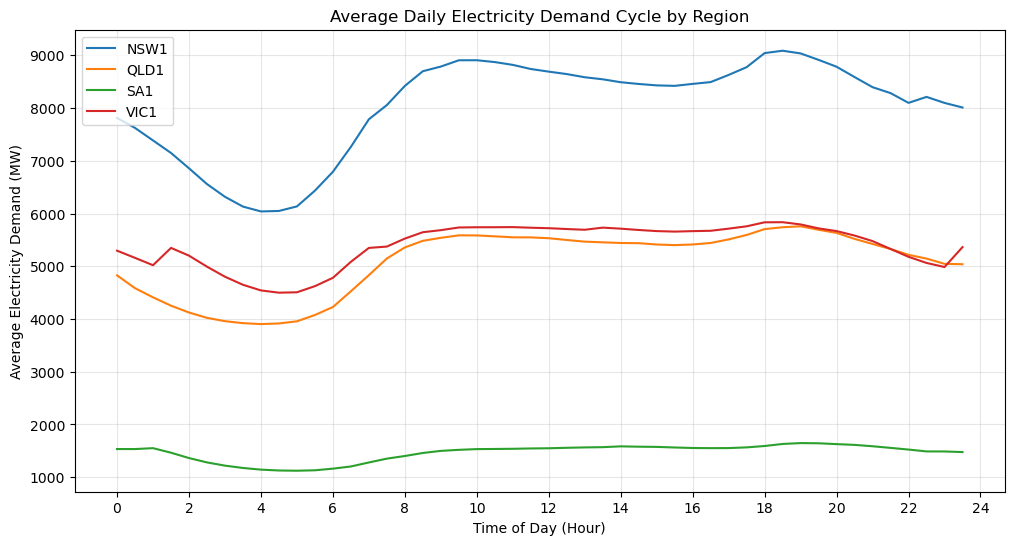

In [22]:
import matplotlib.pyplot as plt

# Daily demand cycle
# Create hour variable
# Use hour + minute so half-hour observations are preserved
demand["TIME_OF_DAY"] = (
    demand["SETTLEMENTDATE"].dt.hour
    + demand["SETTLEMENTDATE"].dt.minute / 60
)

# Calculate average demand for each half-hour
daily_cycle = (
    demand
    .groupby(["REGION", "TIME_OF_DAY"])["TOTALDEMAND"]
    .mean()
    .reset_index()
)

# Plot
plt.figure(figsize=(12, 6))

for region in daily_cycle["REGION"].unique():
    
    region_data = daily_cycle[
        daily_cycle["REGION"] == region
    ]
    
    plt.plot(
        region_data["TIME_OF_DAY"],
        region_data["TOTALDEMAND"],
        label=region
    )

plt.xlabel("Time of Day (Hour)")
plt.ylabel("Average Electricity Demand (MW)")
plt.title("Average Daily Electricity Demand Cycle by Region")

plt.xticks(range(0, 25, 2))

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [30]:
# ============================================================
# Research Question:
# At what temperature is electricity demand at the lowest,
# and how does this temperature differ between states?
# ============================================================

# ------------------------------------------------------------
# 1. Create 1-degree temperature bins
# ------------------------------------------------------------

analysis = merged.copy()

analysis["TEMP_BIN"] = np.floor(
    analysis["TEMPERATURE"]
).astype(int)


# ------------------------------------------------------------
# 2. Calculate average demand for each temperature bin
# ------------------------------------------------------------

temp_demand = (
    analysis
    .groupby(["REGION", "TEMP_BIN"])
    .agg(
        AVG_DEMAND=("TOTALDEMAND", "mean"),
        N=("TOTALDEMAND", "size")
    )
    .reset_index()
)


# ------------------------------------------------------------
# 3. Remove temperature bins with very few observations
# ------------------------------------------------------------
# Rare temperatures can produce unreliable averages.

temp_demand_filtered = temp_demand[
    temp_demand["N"] >= 100
].copy()


# ------------------------------------------------------------
# 4. Find temperature with lowest average demand
# ------------------------------------------------------------

lowest_index = (
    temp_demand_filtered
    .groupby("REGION")["AVG_DEMAND"]
    .idxmin()
)

comfortable_temperature = (
    temp_demand_filtered
    .loc[
        lowest_index,
        ["REGION", "TEMP_BIN", "AVG_DEMAND", "N"]
    ]
    .sort_values("REGION")
    .reset_index(drop=True)
)

comfortable_temperature["TEMPERATURE_RANGE"] = (
    comfortable_temperature["TEMP_BIN"].astype(str)
    + "–"
    + (comfortable_temperature["TEMP_BIN"] + 1).astype(str)
    + "°C"
)

print("=" * 60)
print("Temperature associated with lowest average demand")
print("=" * 60)

display(
    comfortable_temperature[
        [
            "REGION",
            "TEMPERATURE_RANGE",
            "AVG_DEMAND",
            "N"
        ]
    ].round(2)
)

Temperature associated with lowest average demand


,REGION,TEMPERATURE_RANGE,AVG_DEMAND,N
0,NSW1,19–20°C,7566.05,4115
1,QLD1,7–8°C,4432.51,303
2,SA1,3–4°C,1254.25,101
3,VIC1,17–18°C,5220.47,3398


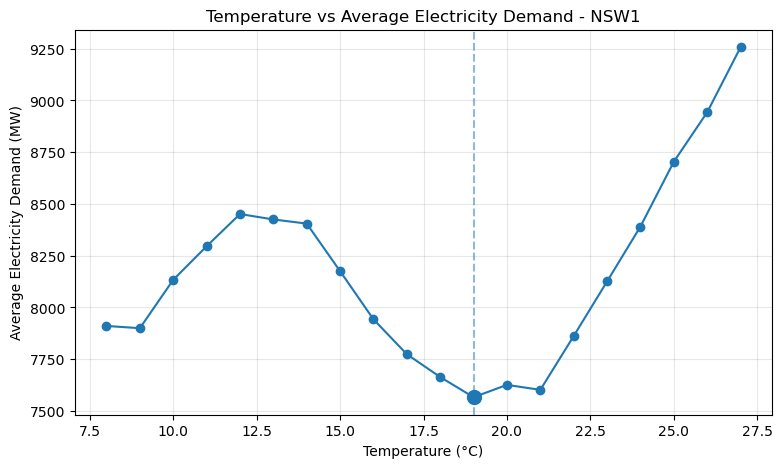

NSW1: lowest average demand occurs around 19–20°C (N = 4115)


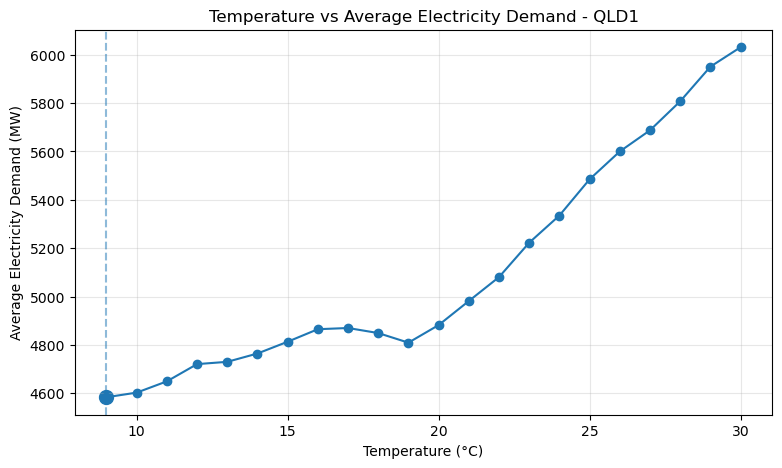

QLD1: lowest average demand occurs around 9–10°C (N = 650)


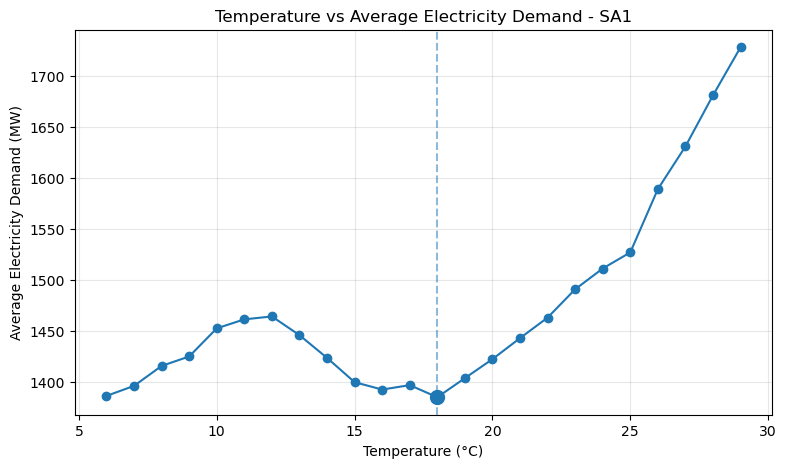

SA1: lowest average demand occurs around 18–19°C (N = 2732)


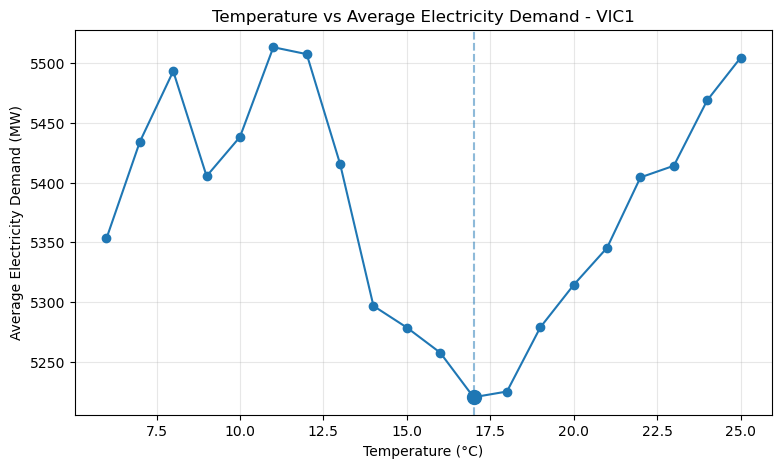

VIC1: lowest average demand occurs around 17–18°C (N = 3398)


In [31]:
import matplotlib.pyplot as plt
import numpy as np

# Create 1-degree temperature bins
analysis = merged.copy()

analysis["TEMP_BIN"] = np.floor(analysis["TEMPERATURE"])

# Calculate average demand and number of observations
temp_demand = (
    analysis
    .groupby(["REGION", "TEMP_BIN"])
    .agg(
        AVG_DEMAND=("TOTALDEMAND", "mean"),
        N=("TOTALDEMAND", "size")
    )
    .reset_index()
)

# Only keep temperature bins with at least 500 observations
temp_demand_filtered = temp_demand[
    temp_demand["N"] >= 500
].copy()

# Plot each state separately
regions = ["NSW1", "QLD1", "SA1", "VIC1"]

for region in regions:
    
    state = temp_demand_filtered[
        temp_demand_filtered["REGION"] == region
    ].sort_values("TEMP_BIN")
    
    plt.figure(figsize=(9, 5))
    
    plt.plot(
        state["TEMP_BIN"],
        state["AVG_DEMAND"],
        marker="o"
    )
    
    # Find lowest point
    lowest = state.loc[state["AVG_DEMAND"].idxmin()]
    
    plt.scatter(
        lowest["TEMP_BIN"],
        lowest["AVG_DEMAND"],
        s=100
    )
    
    plt.axvline(
        lowest["TEMP_BIN"],
        linestyle="--",
        alpha=0.5
    )
    
    plt.title(
        f"Temperature vs Average Electricity Demand - {region}"
    )
    
    plt.xlabel("Temperature (°C)")
    plt.ylabel("Average Electricity Demand (MW)")
    plt.grid(True, alpha=0.3)
    
    plt.show()
    
    print(
        f"{region}: lowest average demand occurs around "
        f"{lowest['TEMP_BIN']:.0f}–{lowest['TEMP_BIN'] + 1:.0f}°C "
        f"(N = {int(lowest['N'])})"
    )